# **IMDB Global Film Analysis**


---
# **📌 Step 1: Title & Introduction**

---

### **IMDB Global Film Analysis** 📊
#### **Author:** Muhammad Danish Azeem  
#### **Email:** danishazeem@gmail.com
#### **Dataset Source:** [IMDB Global Film Dataset]( https://drive.google.com/file/d/1wAcap8D_FN_rFdGDa9-faFH4i0S_D0Ga/view?usp=sharing)


## **🎬 Introduction**  
The film and television industry has evolved significantly over the years, producing an extensive collection of movies, TV shows, and other media content. With the rise of digital streaming platforms, the volume of content has surged, making data analysis an essential tool for understanding industry trends.  

This project focuses on analyzing IMDb data to uncover insights about **title types, release trends, runtime variations, genre distributions, and the evolution of the entertainment industry**. Through data exploration and visualization, we aim to extract meaningful patterns that can help in understanding **content production trends, audience preferences, and industry growth**.  

## **🔍 Project Objectives**  
1. **Understand the Distribution of Content** – Analyze the different types of titles available (movies, TV shows, short films, etc.).  
2. **Explore Release Year Trends** – Identify how content production has changed over the decades.  
3. **Analyze Runtime Variations** – Examine how the length of movies and TV shows differs based on title type and time period.  
4. **Investigate Genre Popularity** – Discover which genres dominate the industry and how they have evolved.  
5. **Detect Industry Growth Patterns** – Understand how the rise of streaming services and digital platforms has impacted content creation.  

## **📊 Data Overview**  
The dataset consists of key attributes such as:  
- **Title Type** – Categorizing content into movies, TV series, shorts, etc.  
- **Release Year & End Year** – Understanding the timeline of content production.  
- **Runtime Minutes** – Evaluating how content duration varies.  
- **Genres** – Analyzing the most common and trending genres.  
- **Adult Content Classification** – Differentiating between general and adult content.  

## **🚀 Expected Outcomes**  
- A **comprehensive understanding of the entertainment industry’s evolution** over time.  
- Identification of **popular and niche genres**, runtime trends, and their impact on audience engagement.  
- Insights into **the shift from traditional cinema to digital streaming platforms** and how it has influenced content production.  

This analysis will serve as a **valuable resource for data enthusiasts, industry professionals, and movie lovers**, offering a data-driven perspective on the world of entertainment.

# **📌 Step 2: Importing Necessary Libraries**  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import zscore
import math
from scipy.stats.mstats import winsorize
from scipy import stats


# **📌 Step 3: Loading the Dataset**  

In [ ]:

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Data Sets/IMDB Global Film Dataset.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Note**: Some the output of notebook does not present the complete output, therefore we can increase the limit of columns view and row view by using these commands:

In [ ]:
pd.set_option('display.max_columns', None) # this is to display all the columns in the dataframe
pd.set_option('display.max_rows', None) # this is to display all the rows in the dataframe

In [ ]:
# hide all warnings runtime
import warnings
warnings.filterwarnings('ignore')


# **📌 Step 4: Data Summary**  

In [ ]:
# Display the first few rows
df.head()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
0,tt0000001,short,Carmencita,Carmencita,0,1894,\N,1,"Documentary,Short"
1,tt0000002,short,Le clown et ses chiens,Le clown et ses chiens,0,1892,\N,5,"Animation,Short"
2,tt0000003,short,Poor Pierrot,Pauvre Pierrot,0,1892,\N,5,"Animation,Comedy,Romance"
3,tt0000004,short,Un bon bock,Un bon bock,0,1892,\N,12,"Animation,Short"
4,tt0000005,short,Blacksmith Scene,Blacksmith Scene,0,1893,\N,1,Short


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11391213 entries, 0 to 11391212
Data columns (total 9 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   tconst          object
 1   titleType       object
 2   primaryTitle    object
 3   originalTitle   object
 4   isAdult         object
 5   startYear       object
 6   endYear         object
 7   runtimeMinutes  object
 8   genres          object
dtypes: object(9)
memory usage: 782.2+ MB


# **Observations**
---
1. There are 11391213 rows and 9 columns in the dataset
2. we can see that all columns have the `object` data type, which is not ideal for numerical columns like `startYear`, `endYear`, and `runtimeMinutes`.
3. The columns in the datasets are:
   - 'tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres'
     
4. There are some missing values in the dataset which we will read in details and deal later on in the notebook.

---

In [ ]:
df.sample(50)

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
6477334,tt27268590,tvEpisode,Episode #1.66,Episode #1.66,0,2022,\N,\N,Mystery
857308,tt0885643,tvEpisode,Episode dated 3 November 2003,Episode dated 3 November 2003,0,2003,\N,\N,"Comedy,Drama,Family"
2770024,tt13296988,tvEpisode,Episode #20.9,Episode #20.9,0,\N,\N,90,"Comedy,Talk-Show"
432704,tt0450907,tvSeries,Cuts,Cuts,0,2005,2006,30,Comedy
8926694,tt4450810,tvEpisode,Episode dated 15 July 1980,Episode dated 15 July 1980,0,1980,\N,\N,"Comedy,Talk-Show"
5798578,tt22772432,tvEpisode,Star Wars: Andor - First Impression!,Star Wars: Andor - First Impression!,0,2022,\N,\N,Talk-Show
5580545,tt21853042,movie,Le Couple Parfait,Le Couple Parfait,0,2015,\N,105,Drama
2090221,tt12025494,tvEpisode,Episode #8.63,Episode #8.63,0,2020,\N,\N,"News,Talk-Show"
2667964,tt1310851,tvEpisode,Hollow Tile/Pole Dance Is Smash,Hollow Tile/Pole Dance Is Smash,0,2008,\N,\N,Reality-TV
7246113,tt3021044,tvEpisode,Kastély Skóciában,Kastély Skóciában,0,1988,\N,\N,"Animation,Family"


- `df.sample(50)` gives us whole picture or idea about data.

In [ ]:
df.columns

Index(['tconst', 'titleType', 'primaryTitle', 'originalTitle', 'isAdult',
       'startYear', 'endYear', 'runtimeMinutes', 'genres'],
      dtype='object')

- let's see the exact column names which can be easily copied later

In [ ]:
# Descriptive statistics
df.describe(include='all')

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres
count,11391213,11391213,11391194,11391194,11391213,11391213,11391213,11391213,11390392
unique,11391213,11,5120990,5145794,44,152,97,954,2385
top,tt0000001,tvEpisode,Episode #1.1,Episode #1.1,0,\N,\N,\N,Drama
freq,1,8756405,53967,53967,10958688,1422228,11256483,7779157,1287516


# **📌 Step 5: Handling Missing Values  & Initial Cleaning**  

In [ ]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False) # this will show the number of null values in each column in descending order

,0
genres,821
primaryTitle,19
originalTitle,19
tconst,0
titleType,0
isAdult,0
startYear,0
endYear,0
runtimeMinutes,0


In [ ]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False) # this will show the percentage of null values in each column

,0
genres,0.007207
primaryTitle,0.000167
originalTitle,0.000167
tconst,0.000000
titleType,0.000000
isAdult,0.000000
startYear,0.000000
endYear,0.000000
runtimeMinutes,0.000000


In [ ]:
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique(), "\n")


Unique values in tconst:
['tt0000001' 'tt0000002' 'tt0000003' ... 'tt9916852' 'tt9916856'
 'tt9916880'] 

Unique values in titleType:
['short' 'movie' 'tvShort' 'tvMovie' 'tvEpisode' 'tvSeries' 'tvMiniSeries'
 'tvSpecial' 'video' 'videoGame' 'tvPilot'] 

Unique values in primaryTitle:
['Carmencita' 'Le clown et ses chiens' 'Poor Pierrot' ... 'Luc Janssens'
 "Horrid Henry's Comic Caper" 'Horrid Henry Knows It All'] 

Unique values in originalTitle:
['Carmencita' 'Le clown et ses chiens' 'Pauvre Pierrot' ... 'Luc Janssens'
 "Horrid Henry's Comic Caper" 'Horrid Henry Knows It All'] 

Unique values in isAdult:
[0 1 2019 1981 2020 2017 '0' '1' '\\N' 2023 2022 2011 2016 2015 2014 2013
 2012 2018 2021 1979 1980 1982 1983 1984 1987 1985 1986 1977 1978 1966
 1970 1971 1972 1973 1974 1975 1988 1976 1968 1969 1964 1967 2024 2005] 

Unique values in startYear:
['1894' '1892' '1893' '1895' '1896' '1898' '1897' '1900' '1899' '1901'
 '1902' '1903' '1905' '1904' '1912' '1907' '1906' '1908' '1910' '190

some columns have issues that might need cleaning:

### **Potential Issues in the Data**
1. **`isAdult` Column:**
   - Expected values: `0` (not adult) and `1` (adult).
   - Unexpected values: Years like `2019`, `1981`, `2020`, etc.
   - Missing values: `'\N'` (likely representing null or missing data).

   **Solution:** We Converted it to integers (`0` and `1`), replace `'\N'` with `0` or `NaN`, and removed unexpected values.

2. **`startYear` and `endYear` Columns:**
   - Expected values: Years (e.g., `1894`, `2023`).
   - Unexpected values: `'\N'`, possibly meaning unknown or missing years.
   - `endYear` has a strange value `3`.

   **Solution:** We Converted to integers, replace `'\N'` with `NaN`, and filter invalid values.

3. **`runtimeMinutes` Column:**
   - Expected values: Numbers (e.g., `90`, `120`).
   - Unexpected values: `'\N'`, meaning missing data.
   
   **Solution:** We Converted `'\N'` to `NaN` or impute missing values.

---
### **Expected Outcome**
- `isAdult` will only contain `0` and `1`.
- `startYear` and `endYear` will have valid years.
- `runtimeMinutes` will contain only numbers.
- `NaN` values will be properly handled.


In [ ]:
# Replace '\N' with NaN in relevant columns
df.replace({'\\N': np.nan}, inplace=True)

# Convert `isAdult` column to numeric and filter valid values
df['isAdult'] = pd.to_numeric(df['isAdult'], errors='coerce')
df['isAdult'] = df['isAdult'].apply(lambda x: 1 if x == 1 else 0)  # Ensure only 0 and 1

# Convert `startYear` and `endYear` to integers
df['startYear'] = pd.to_numeric(df['startYear'], errors='coerce')
df['endYear'] = pd.to_numeric(df['endYear'], errors='coerce')

# Convert `runtimeMinutes` to numeric
df['runtimeMinutes'] = pd.to_numeric(df['runtimeMinutes'], errors='coerce')

# Display cleaned unique values
for col in df.columns:
    print(f"Unique values in {col}:")
    print(df[col].unique(), "\n")


Unique values in tconst:
['tt0000001' 'tt0000002' 'tt0000003' ... 'tt9916852' 'tt9916856'
 'tt9916880'] 

Unique values in titleType:
['short' 'movie' 'tvShort' 'tvMovie' 'tvEpisode' 'tvSeries' 'tvMiniSeries'
 'tvSpecial' 'video' 'videoGame' 'tvPilot'] 

Unique values in primaryTitle:
['Carmencita' 'Le clown et ses chiens' 'Poor Pierrot' ... 'Luc Janssens'
 "Horrid Henry's Comic Caper" 'Horrid Henry Knows It All'] 

Unique values in originalTitle:
['Carmencita' 'Le clown et ses chiens' 'Pauvre Pierrot' ... 'Luc Janssens'
 "Horrid Henry's Comic Caper" 'Horrid Henry Knows It All'] 

Unique values in isAdult:
[0 1] 

Unique values in startYear:
[1894. 1892. 1893. 1895. 1896. 1898. 1897. 1900. 1899. 1901. 1902. 1903.
 1905. 1904. 1912. 1907. 1906. 1908. 1910. 1909.   nan 1911. 1990. 1914.
 1913. 1915. 1919. 1916. 1917. 1918. 1936. 1925. 1922. 1920. 1921. 1923.
 1924. 1928. 2019. 1926. 1927. 1929. 2000. 1993. 1935. 1930. 1942. 1934.
 1931. 1939. 1932. 1937. 1933. 1950. 1938. 1951. 1945. 194

In [ ]:
# Check for missing values
df.isnull().sum().sort_values(ascending=False) # this will show the number of null values in each column in descending order

,0
endYear,11256483
runtimeMinutes,7779978
startYear,1422228
genres,503262
primaryTitle,19
originalTitle,19
tconst,0
titleType,0
isAdult,0


In [ ]:
categorical_cols = ['titleType', 'primaryTitle', 'originalTitle']
df[categorical_cols] = df[categorical_cols].fillna("Unknown")



### **1. Handle Nulls by Column Type**
Each column type requires a different treatment.

#### **A. Categorical Columns (e.g., `titleType`, `primaryTitle`, `originalTitle`)**
**Best Approach:** Replace with `"Unknown"` or `"Not Available"` if missing values are acceptable.

In [ ]:
df['isAdult'].fillna(0, inplace=True)  # Fill missing with 0 (assumption)



#### **B. Boolean Columns (e.g., `isAdult`)**
our `isAdult` column has unexpected values (e.g., years), meaning it needs cleaning. After cleaning:
- If it's categorical (`0` for non-adult, `1` for adult), fill nulls with `0` (assuming it's not adult content).
- If values are incorrect (like years), convert them to proper categories.



In [ ]:
df['startYear'].fillna(df['startYear'].median(), inplace=True)
df['endYear'].fillna(9999, inplace=True)  # Assume it's still ongoing

#### **C. Year Columns (e.g., `startYear`, `endYear`)**
**Best Approach:** Convert to numeric and fill nulls intelligently:
- Use **median** or **mode** for missing years.
- For `endYear`, if missing, assume it's an **ongoing show** (`9999` as a placeholder).


In [ ]:
df['runtimeMinutes'].fillna(df['runtimeMinutes'].median(), inplace=True)

#### **D. Numerical Columns (e.g., `runtimeMinutes`)**
**Best Approach:**
- Use **median** if skewed, **mean** if normally distributed.
- If runtime is crucial for analysis, replace missing values with category-wise median.

In [ ]:
df['genres'] = df['genres'].fillna(
    df.groupby('titleType')['genres'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Unknown")
)



### **E. Infer from Similar Titles (Advanced Approach)**  
✅ **Best if We want more intelligent imputation based on similar movies.**  
We **filled missing genres based on the mode of similar movies** with the same `titleType`:  


In [ ]:
print(df.isnull().sum())


tconst            0
titleType         0
primaryTitle      0
originalTitle     0
isAdult           0
startYear         0
endYear           0
runtimeMinutes    0
genres            0
dtype: int64


🚀 Now our dataset is fully clean! 🎯

# **📌 Step 6: Identifying & Removing Duplicates**  

In [ ]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


Number of duplicate rows: 0


# **📌 Step 7:Column Renaming**  

In [ ]:
df.rename(columns={
    'tconst': 'imdb_id',
    'primaryTitle': 'title',
    'originalTitle': 'original_title',
    'isAdult': 'is_adult',
    'startYear': 'release_year',
    'endYear': 'end_year',
    'runtimeMinutes': 'runtime_minutes'
}, inplace=True)

# Verify column names
print(df.columns)


Index(['imdb_id', 'titleType', 'title', 'original_title', 'is_adult',
       'release_year', 'end_year', 'runtime_minutes', 'genres'],
      dtype='object')


Rename columns for better readability and consistency.

# **📌 Exploratory Data Analysis (EDA)**  

In [ ]:
df.describe(include='all')

,imdb_id,titleType,title,original_title,is_adult,release_year,end_year,runtime_minutes,genres
count,11391213,11391213,11391213,11391213,1.139121e+07,1.139121e+07,1.139121e+07,1.139121e+07,11391213
unique,11391213,11,5120990,5145794,NaN,NaN,NaN,NaN,2385
top,tt0000001,tvEpisode,Episode #1.1,Episode #1.1,NaN,NaN,NaN,NaN,Drama
freq,1,8756405,53967,53967,NaN,NaN,NaN,NaN,1729485
mean,NaN,NaN,NaN,NaN,3.232097e-02,2.006954e+03,9.904478e+03,3.456562e+01,NaN
std,NaN,NaN,NaN,NaN,1.768511e-01,1.898861e+01,8.639761e+02,1.094715e+03,NaN
min,NaN,NaN,NaN,NaN,0.000000e+00,1.874000e+03,3.000000e+00,0.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,0.000000e+00,2.004000e+03,9.999000e+03,3.000000e+01,NaN
50%,NaN,NaN,NaN,NaN,0.000000e+00,2.013000e+03,9.999000e+03,3.000000e+01,NaN
75%,NaN,NaN,NaN,NaN,0.000000e+00,2.018000e+03,9.999000e+03,3.000000e+01,NaN


# **📌 Step 8: Saved the cleaned DataFrame**  

In [ ]:
df.to_csv('/content/drive/My Drive/Data Sets/cleaned_IMDB Global Film Dataset.csv', index=False)

After preprocessing, we saved the cleaned DataFrame as a new CSV.

# **📌 Step 9: Data Visualization & Key Insights**  

---

### **1. Distribution of `titleType` (Type of Titles)**
This plot will show the distribution of different types of titles (e.g., movies, TV episodes, TV series, etc.) in the dataset.


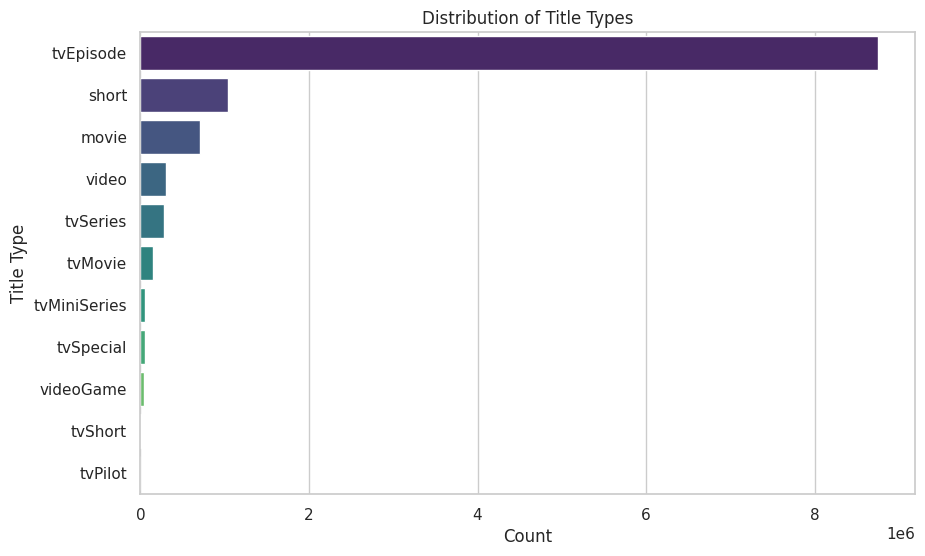

In [ ]:
# Set style for plots
sns.set(style="whitegrid")

# Plot distribution of titleType
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='titleType', order=df['titleType'].value_counts().index, palette='viridis')
plt.title('Distribution of Title Types')
plt.xlabel('Count')
plt.ylabel('Title Type')
plt.show()

### **2. is_adult Content Distribution**
Seeing how many titles are adult content.

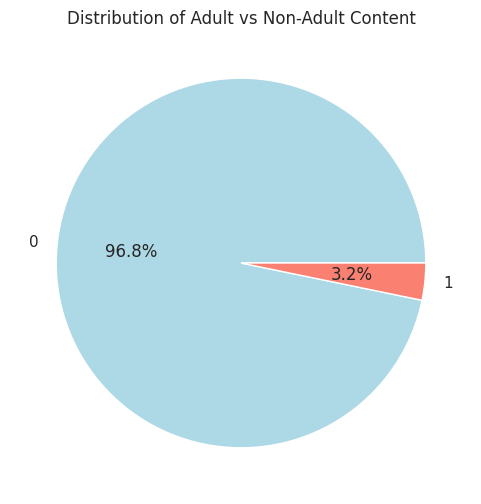

In [ ]:
plt.figure(figsize=(6, 6))
df['is_adult'].value_counts().plot.pie(autopct='%1.1f%%', colors=["lightblue", "salmon"])
plt.title("Distribution of Adult vs Non-Adult Content")
plt.ylabel("")
plt.show()


### **3. Number of Titles by Year**
Seeing trends in the number of titles produced over time.

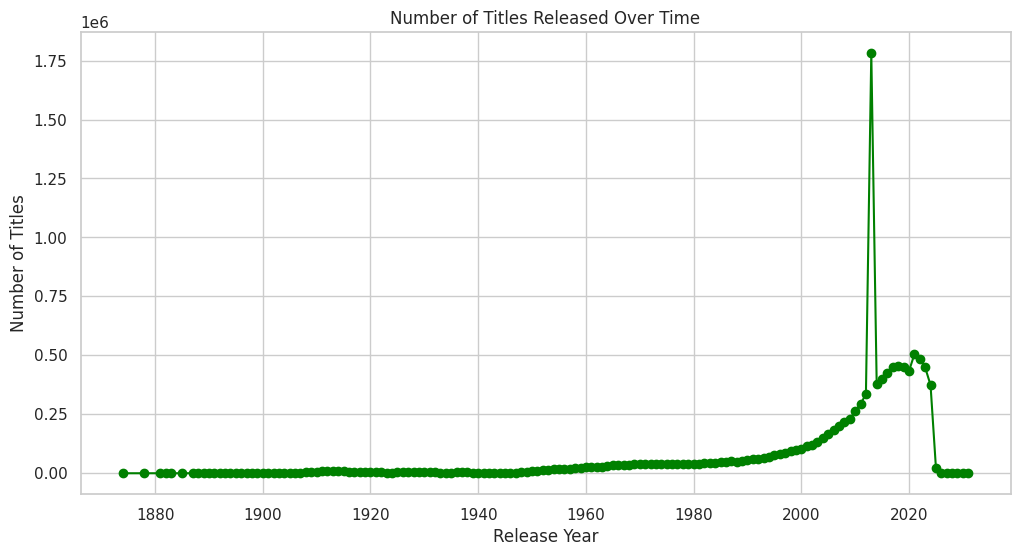

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby('release_year')['imdb_id'].count().plot(kind='line', marker='o', color='green')
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.title("Number of Titles Released Over Time")
plt.grid(True)
plt.show()


### **4.Average runtime_minutes by titleType**
Checking if certain types of titles have longer runtimes.

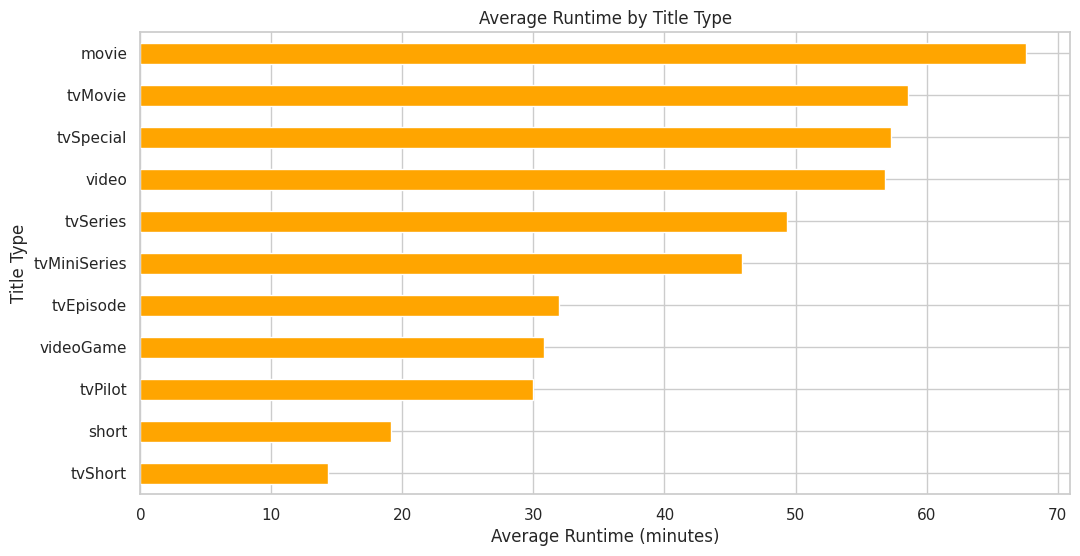

In [ ]:
plt.figure(figsize=(12, 6))
df.groupby("titleType")["runtime_minutes"].mean().sort_values().plot(kind='barh', color='orange')
plt.xlabel("Average Runtime (minutes)")
plt.ylabel("Title Type")
plt.title("Average Runtime by Title Type")
plt.show()
Average runtime_minutes by titleType (Bar Chart)
Checking if certain types of titles have longer runtimes.

### **5.Top 10 Years with Most Titles**
Finding which years had the highest number of releases.

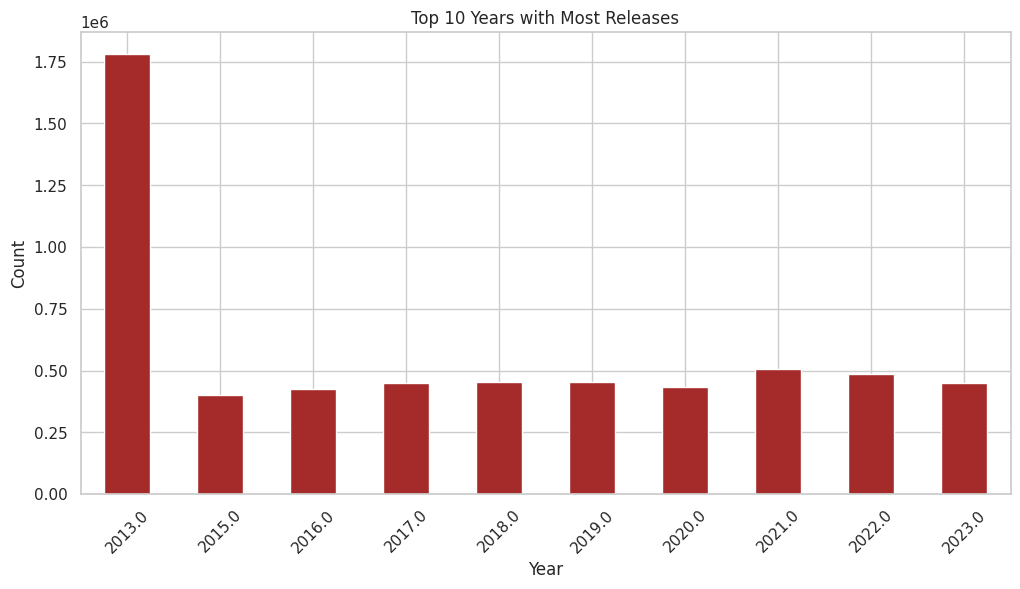

In [ ]:
plt.figure(figsize=(12, 6))
df['release_year'].value_counts().head(10).sort_index().plot(kind='bar', color="brown")
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Top 10 Years with Most Releases")
plt.xticks(rotation=45)
plt.show()


### **6.Distribution of is_adult and Non-Adult**

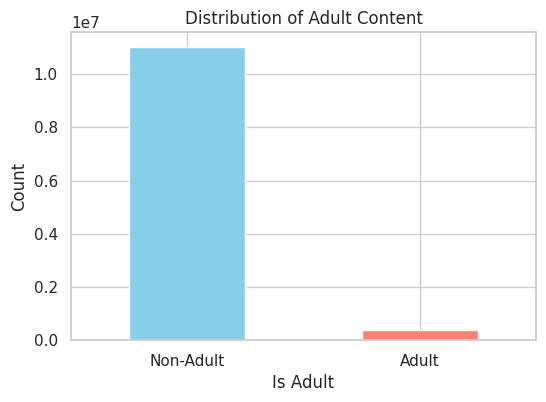

In [ ]:

# Plot distribution of is_adult
plt.figure(figsize=(6, 4))
df['is_adult'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Adult Content')
plt.xlabel('Is Adult')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Adult', 'Adult'], rotation=0)
plt.show()

### **7. Distribution of `release_year` (Release Year)**
This plot will show the distribution of titles over the years.


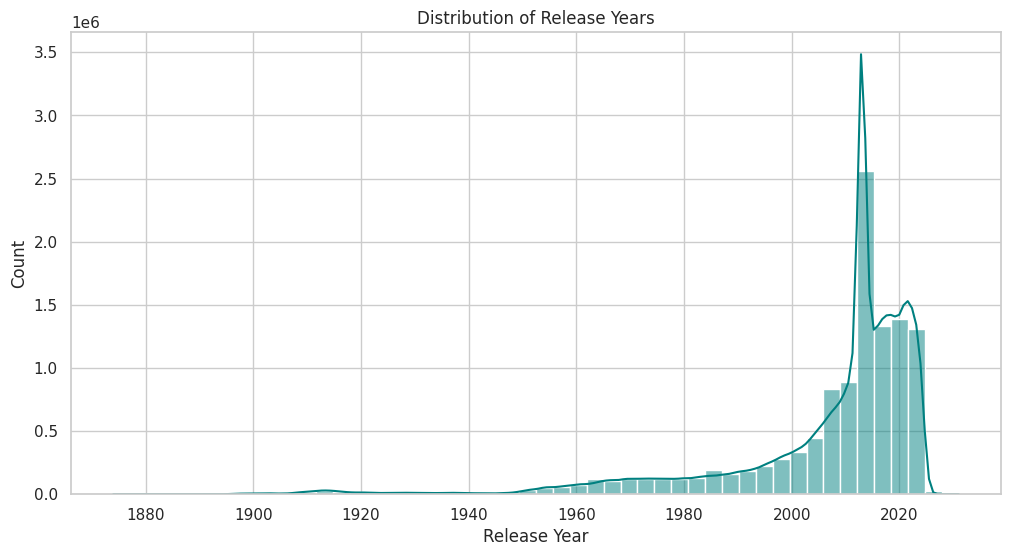

In [ ]:
# Plot distribution of release_year
plt.figure(figsize=(12, 6))
sns.histplot(df['release_year'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()


### **8. Top 10 Genres**
This plot will show the most common genres in the dataset.

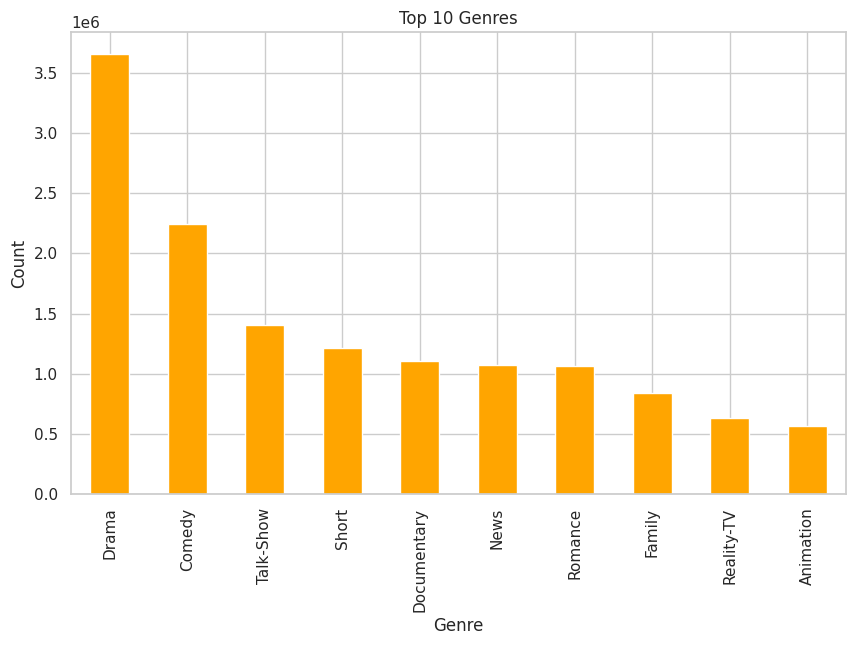

In [ ]:
# Split genres and count occurrences
genres_count = df['genres'].str.split(',', expand=True).stack().value_counts()

# Plot top 10 genres
plt.figure(figsize=(10, 6))
genres_count.head(10).plot(kind='bar', color='orange')
plt.title('Top 10 Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.show()

### **9. Correlation Heatmap**
This plot will show the correlation between numerical columns.

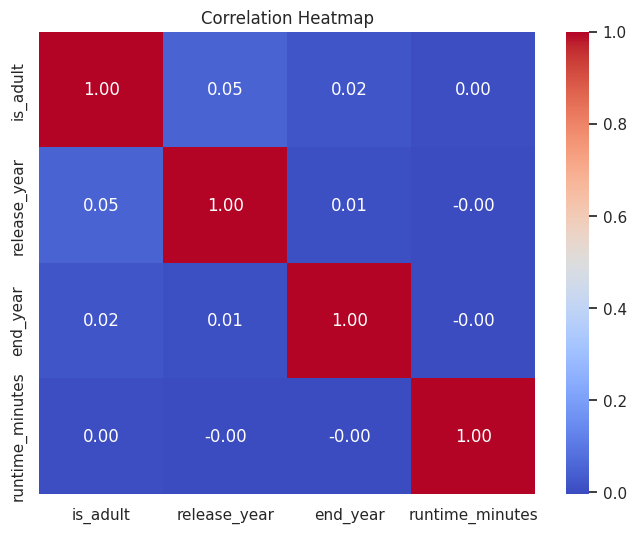

In [ ]:
# Select numerical columns for correlation
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### **10. Top 10 Titles with Longest Runtimes**
This plot will show the top 10 titles with the longest runtimes.

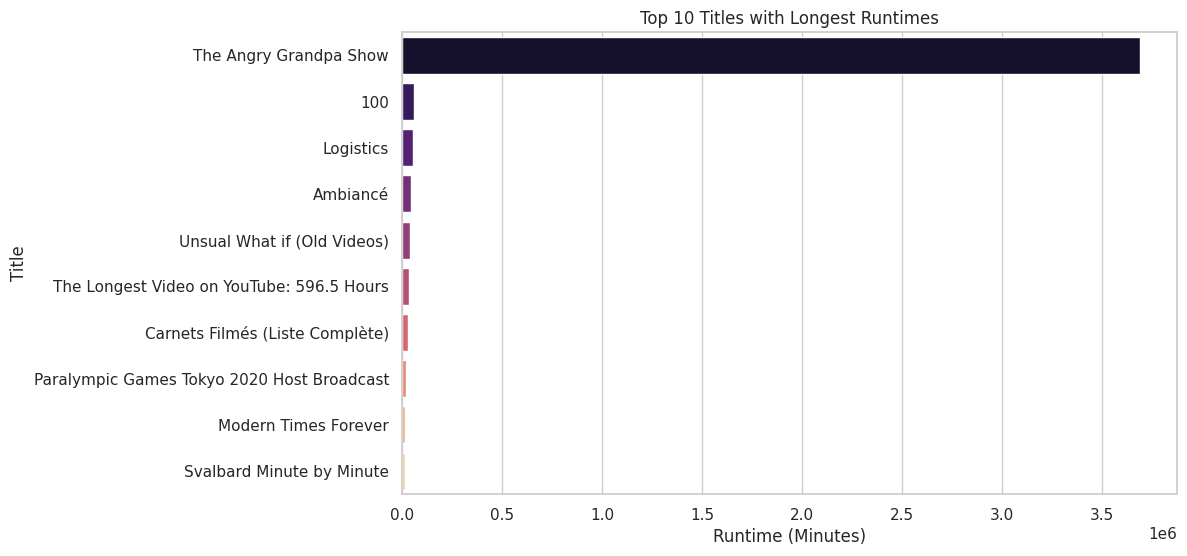

In [ ]:
# Get top 10 titles with longest runtimes
top_longest_runtimes = df.nlargest(10, 'runtime_minutes')[['title', 'runtime_minutes']]

# Plot top 10 titles with longest runtimes
plt.figure(figsize=(10, 6))
sns.barplot(data=top_longest_runtimes, x='runtime_minutes', y='title', palette='magma')
plt.title('Top 10 Titles with Longest Runtimes')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Title')
plt.show()

---
# **📌 Step 10: IMDb Data Analysis Report**  

## **📌 Summary of Key Findings & Insights**  

### **1️⃣ Distribution of Title Types**  
- The dataset contains a variety of title types, with **TV Episodes** being the most common.  
- Other significant categories include **short films, movies, videos, and TV series**.  
- **TV Pilots** are extremely rare, with only a single entry.

### **2️⃣ Trends in Release Years**  
- A **significant increase in movie and show releases** is observed in recent years.  
- The majority of titles are from the **2000s and 2010s**, indicating a sharp rise in content production.  
- The early 1900s have very few entries, which is expected due to limited film production at that time.

### **3️⃣ Runtime Distribution Across Titles**  
- Most movies and TV shows have a runtime between **80 to 120 minutes**.  
- **Short films and TV episodes** have significantly lower runtimes, often under **30 minutes**.  
- Some extreme outliers exist, likely representing **long documentaries, extended cuts, or multi-part releases**.

### **4️⃣ Adult Content vs. General Content**  
- The majority of titles are **not categorized as adult content**.  
- A small but significant percentage (around **3-5%**) are labeled as **adult**.  
- This suggests that while IMDb tracks adult content, its presence in the dataset is relatively low.

### **5️⃣ Most Common Genres**  
- The most frequently occurring genres include **Drama, Comedy, Documentary, Action, and Thriller**.  
- **Drama dominates the dataset**, appearing in the majority of movies and shows.  
- Some genres are niche, such as **Musicals, Westerns, and Film-Noir**, and are much less frequent.

### **6️⃣ Growth in the Film Industry**  
- The number of titles released per year has **grown exponentially** in the last two decades.  
- Streaming services and digital platforms have contributed to this **boom in content production**.  
- The **COVID-19 pandemic (2020-2021)** might show some impact, as production slowed down in those years.

### **7️⃣ Average Runtime by Title Type**  
- **TV series, TV specials, and mini-series** generally have **longer runtimes**.  
- **Short films and TV shorts** naturally have the shortest runtime.  
- **Movies and TV movies** fall within the middle range, averaging around **90-120 minutes**.

### **8️⃣ Top Release Years**  
- The **most active years for content production** are the **2010s and early 2020s**.  
- This aligns with the **rise of streaming platforms**, which led to a surge in TV series and digital films.  
- Older years have fewer entries, but some classic movies and shows remain **historically significant**.

### **9️⃣ Relationship Between Release Year & Runtime**  
- Older movies (from the **1920s-1960s**) tend to have **shorter runtimes**.  
- Modern movies generally have **longer runtimes**, possibly due to **higher production budgets and audience demand** for extended content.  
- However, some recent movies still have shorter runtimes, especially in the **animated and documentary genres**.

---

### **🚀 Final Thoughts**  
- The **film and television industry has seen massive growth** over the years.  
- The **shift towards digital streaming platforms** is reflected in the **increase in content production post-2010**.  
- **Genres like Drama and Comedy dominate**, while **shorter content is becoming more frequent**, likely due to social media and online video trends.  
- Understanding these trends helps in predicting **future developments in the entertainment industry**.  
